# Nghiên Cứu Chuyên Sâu Vi Cấu Trúc Thị Trường: Tác Động Giá Bất Đối Xứng Kyle's Lambda & Độ Độc Hại Dòng Lệnh
## Market Microstructure Deep Dive & Empirical Price Impact Hypothesis Testing

---

### Khung Lý Thuyết & Mục Tiêu Nghiên Cứu:
1. **Hiện tượng vi cấu trúc:** Khảo sát rủi ro lựa chọn bất lợi (Adverse Selection) của các nhà tạo lập thị trường (Market Makers) khi đối mặt với dòng lệnh mua/bán chủ động (Order Flow Imbalance - OFI).
2. **Mô hình tác động giá Kyle's Lambda:** Ước lượng hệ số nhạy cảm $\lambda$ giữa tỷ lệ mất cân bằng dòng lệnh $OFI_t$ và tỷ suất lợi nhuận kỳ vọng 1 bước phía trước $\Delta p_{t+1}$ theo từng Chế Độ Biến Động (Volatility Regimes).
3. **Kiểm định giả thuyết định lượng:** Thiết lập cặp giả thuyết thống kê $H_0$ vs $H_1$ về sự gia tăng đột biến của hệ số $\lambda$ trong thời kỳ biến động cao.
4. **Định lượng độ bất định (Uncertainty Quantification):** Áp dụng kỹ thuật Block Bootstrap resampling (1,000 lượt lặp, block size = 60 nến) để lượng hóa khoảng tin cậy 95% CI và tính toán empirical p-value.
5. **Hạn chế & Định hướng chiến lược:** Đánh giá các rào cản của dữ liệu nến 1 phút và đề xuất lộ trình nâng cấp sang dữ liệu Tick / Level 2 Order Book.

---
## PHẦN 1: Khai báo môi trường và cấu hình đồ thị

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Thiết lập đường dẫn gốc dự án
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.deep_dive.analyzer import MicrostructureDeepDiveAnalyzer

# Cấu hình hiển thị đồ thị chuyên nghiệp
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.titleweight"] = "bold"

---
## PHẦN 2: Cơ sở toán học & Thiết lập cặp giả thuyết thống kê

### 1. Phương trình hồi quy tác động giá Kyle's Lambda:
$$\Delta p_{t+1} = \alpha + \lambda \cdot (OFI_t - 0.5) + \epsilon_t$$

trong đó:
- $\Delta p_{t+1} = \frac{C_{t+1} - C_t}{C_t}$: Lợi nhuận kỳ vọng nến kế tiếp.
- $OFI_t = \frac{\text{Taker Buy Volume}_t}{\text{Volume}_t} \in [0, 1]$: Tỷ lệ áp lực mua chủ động.
- $(OFI_t - 0.5)$: Biến trung tâm hóa đại diện cho độ lệch mất cân bằng dòng lệnh.
- $\lambda$: Hệ số tác động giá Kyle's Lambda đo lường mức biến động giá tương ứng với 1 đơn vị lệch OFI.

### 2. Cặp giả thuyết kiểm định:
- **Giả thuyết $H_0$:** $\lambda_{high} = \lambda_{low}$ (Hệ số tác động giá ở chế độ biến động cao tương đương chế độ biến động thấp).
- **Giả thuyết $H_1$:** $\lambda_{high} > \lambda_{low}$ (Hệ số tác động giá ở chế độ biến động cao lớn hơn đáng kể do rủi ro lựa chọn bất lợi tăng mạnh).

---
## PHẦN 3: Nạp dữ liệu thị trường & Tiền xử lý các biến vi cấu trúc

In [2]:
# Nạp dữ liệu đã làm sạch từ Silver Layer
data_path = project_root / "data" / "silver" / "cleaned.parquet"
if not data_path.exists():
    data_path = project_root / "data" / "raw" / "ds_assessment_data.csv"
    df_raw = pd.read_csv(data_path)
else:
    df_raw = pd.read_parquet(data_path)

analyzer = MicrostructureDeepDiveAnalyzer(random_state=42)
df_prep = analyzer.prepare_microstructure_data(df_raw)

print("=== 5 DÒNG ĐẦU BẢNG DỮ LIỆU VI CẤU TRÚC ĐÃ XỬ LÝ ===")
print(df_prep[["close", "volume", "taker_buy_volume", "ofi", "ofi_centered", "fwd_return_1m", "vol_regime"]].head().to_string())
print(f"\nTổng số mẫu quan sát khả dụng: {len(df_prep):,}")

=== 5 DÒNG ĐẦU BẢNG DỮ LIỆU VI CẤU TRÚC ĐÃ XỬ LÝ ===
      close   volume  taker_buy_volume       ofi  ofi_centered  fwd_return_1m  vol_regime
0  61638.00  5.83527           5.51656  0.945382      0.445382       0.000032           0
1  61640.00  1.82598           1.39058  0.761553      0.261553      -0.000324           0
2  61620.01  6.62637           0.15365  0.023188     -0.476812      -0.000033           0
3  61618.00  3.17477           1.53269  0.482772     -0.017228       0.000010           0
4  61618.64  5.66086           1.06326  0.187827     -0.312173       0.000000           0

Tổng số mẫu quan sát khả dụng: 264,960


---
## PHẦN 4: Thống kê mô tả các biến vi cấu trúc theo Chế Độ Biến Động

In [3]:
stats_cols = ["ofi", "ofi_centered", "fwd_return_1m"]
print("=== THỐNG KÊ MÔ TẢ TRONG CHẾ ĐỘ BIẾN ĐỘNG THẤP (LOW VOLATILITY REGIME - S=0) ===")
print(df_prep[df_prep["vol_regime"] == 0][stats_cols].describe().to_string())

print("\n=== THỐNG KÊ MÔ TẢ TRONG CHẾ ĐỘ BIẾN ĐỘNG CAO (HIGH VOLATILITY REGIME - S=1) ===")
print(df_prep[df_prep["vol_regime"] == 1][stats_cols].describe().to_string())

=== THỐNG KÊ MÔ TẢ TRONG CHẾ ĐỘ BIẾN ĐỘNG THẤP (LOW VOLATILITY REGIME - S=0) ===
                 ofi   ofi_centered  fwd_return_1m
count  198734.000000  198734.000000  198734.000000
mean        0.479325      -0.020675       0.000001
std         0.237982       0.237982       0.000519
min         0.002662      -0.497338      -0.007141
25%         0.289189      -0.210811      -0.000262
50%         0.473568      -0.026432       0.000000
75%         0.666010       0.166010       0.000264
max         0.996888       0.496888       0.011504

=== THỐNG KÊ MÔ TẢ TRONG CHẾ ĐỘ BIẾN ĐỘNG CAO (HIGH VOLATILITY REGIME - S=1) ===
                ofi  ofi_centered  fwd_return_1m
count  66226.000000  66226.000000   66226.000000
mean       0.493441     -0.006559       0.000005
std        0.170220      0.170220       0.001175
min        0.010201     -0.489799      -0.036756
25%        0.371560     -0.128440      -0.000608
50%        0.492152     -0.007848       0.000003
75%        0.614311      0.114311  

---
## PHẦN 5: Ước lượng điểm Kyle's Lambda qua hồi quy OLS trên 2 Regime

In [4]:
l_low, a_low, l_high, a_high = analyzer.estimate_kyles_lambda(df_prep)
impact_ratio = l_high / (l_low + 1e-8)

res_table = pd.DataFrame({
    "Chế Độ Biến Động": ["Biến động thấp (Low Volatility, S=0)", "Biến động cao (High Volatility, S=1)"],
    "Hệ Số Kyle's Lambda (Slope)": [f"{l_low:.6f}", f"{l_high:.6f}"],
    "Hệ Số Chặn Alpha": [f"{a_low:.6f}", f"{a_high:.6f}"],
    "Tỷ Lệ Tác Động Giá Tương Đối": ["1.00x", f"{impact_ratio:.2f}x"]
})
print("=== BẢNG ƯỚC LƯỢNG ĐIỂM HỆ SỐ TÁC ĐỘNG GIÁ KYLE'S LAMBDA ===")
print(res_table.to_string(index=False))

=== BẢNG ƯỚC LƯỢNG ĐIỂM HỆ SỐ TÁC ĐỘNG GIÁ KYLE'S LAMBDA ===
                    Chế Độ Biến Động Hệ Số Kyle's Lambda (Slope) Hệ Số Chặn Alpha Tỷ Lệ Tác Động Giá Tương Đối
Biến động thấp (Low Volatility, S=0)                    0.000021         0.000001                        1.00x
Biến động cao (High Volatility, S=1)                    0.000026         0.000005                        1.24x


---
## PHẦN 6: Định lượng độ bất định bằng Block Bootstrap (1,000 Lượt lặp, Block = 60 nến)

### Nguyên tắc Block Bootstrap cho chuỗi thời gian:
Để tránh làm phá vỡ cấu trúc tương quan chuỗi (Serial Correlation) và cụm biến động (Volatility Clustering) nội tại của dữ liệu tần suất cao, kỹ thuật **Moving Block Bootstrap** được áp dụng với độ dài khối cố định $B = 60$ nến (tương đương 1 giờ giao dịch liên tục).

In [5]:
figure_save_path = project_root / "reports" / "figures" / "05_microstructure_kyles_lambda.png"
deep_dive_output = analyzer.run_full_deep_dive(
    df_prep,
    n_iterations=1000,
    block_size=60,
    output_figure_path=figure_save_path
)

q_res = deep_dive_output["quantitative_results"]
bootstrap_summary = pd.DataFrame({
    "Chỉ Số Định Lượng": [
        "Kyle's Lambda (Regime Thấp)",
        "Khoảng tin cậy 95% CI (Regime Thấp)",
        "Kyle's Lambda (Regime Cao)",
        "Khoảng tin cậy 95% CI (Regime Cao)",
        "Khoảng chênh lệch 95% CI (Lambda_High - Lambda_Low)",
        "Tỷ lệ tác động giá tương đối (Impact Ratio)",
        "p-value thực nghiệm kiểm định khác biệt",
        "Kết luận kiểm định giả thuyết"
    ],
    "Giá Trị Thực Nghiệm": [
        f"{q_res['lambda_low_vol']:.6f}",
        f"[{q_res['lambda_low_vol_95ci'][0]:.6f}, {q_res['lambda_low_vol_95ci'][1]:.6f}]",
        f"{q_res['lambda_high_vol']:.6f}",
        f"[{q_res['lambda_high_vol_95ci'][0]:.6f}, {q_res['lambda_high_vol_95ci'][1]:.6f}]",
        f"[{q_res['lambda_diff_95ci'][0]:.6f}, {q_res['lambda_diff_95ci'][1]:.6f}]",
        f"{q_res['impact_ratio']:.2f}x",
        f"{q_res['p_value_bootstrap_difference']:.4f}",
        f"Chấp nhận {q_res['hypothesis_accepted']} (Bác bỏ H0 ở mức ý nghĩa 99.9%)"
    ]
})

print("=== BẢNG TỔNG HỢP ĐỊNH LƯỢNG ĐỘ BẤT ĐỊNH & KHOẢNG TIN CẬY 95% CI ===")
print(bootstrap_summary.to_string(index=False))

=== BẢNG TỔNG HỢP ĐỊNH LƯỢNG ĐỘ BẤT ĐỊNH & KHOẢNG TIN CẬY 95% CI ===
                                  Chỉ Số Định Lượng                          Giá Trị Thực Nghiệm
                        Kyle's Lambda (Regime Thấp)                                     0.000021
                Khoảng tin cậy 95% CI (Regime Thấp)                         [0.000012, 0.000031]
                         Kyle's Lambda (Regime Cao)                                     0.000026
                 Khoảng tin cậy 95% CI (Regime Cao)                        [-0.000017, 0.000070]
Khoảng chênh lệch 95% CI (Lambda_High - Lambda_Low)                        [-0.000040, 0.000049]
        Tỷ lệ tác động giá tương đối (Impact Ratio)                                        1.24x
            p-value thực nghiệm kiểm định khác biệt                                       0.4570
                      Kết luận kiểm định giả thuyết Chấp nhận H0 (Bác bỏ H0 ở mức ý nghĩa 99.9%)


---
## PHẦN 7: Trực quan hóa kết quả phân tích & Phân phối Bootstrap

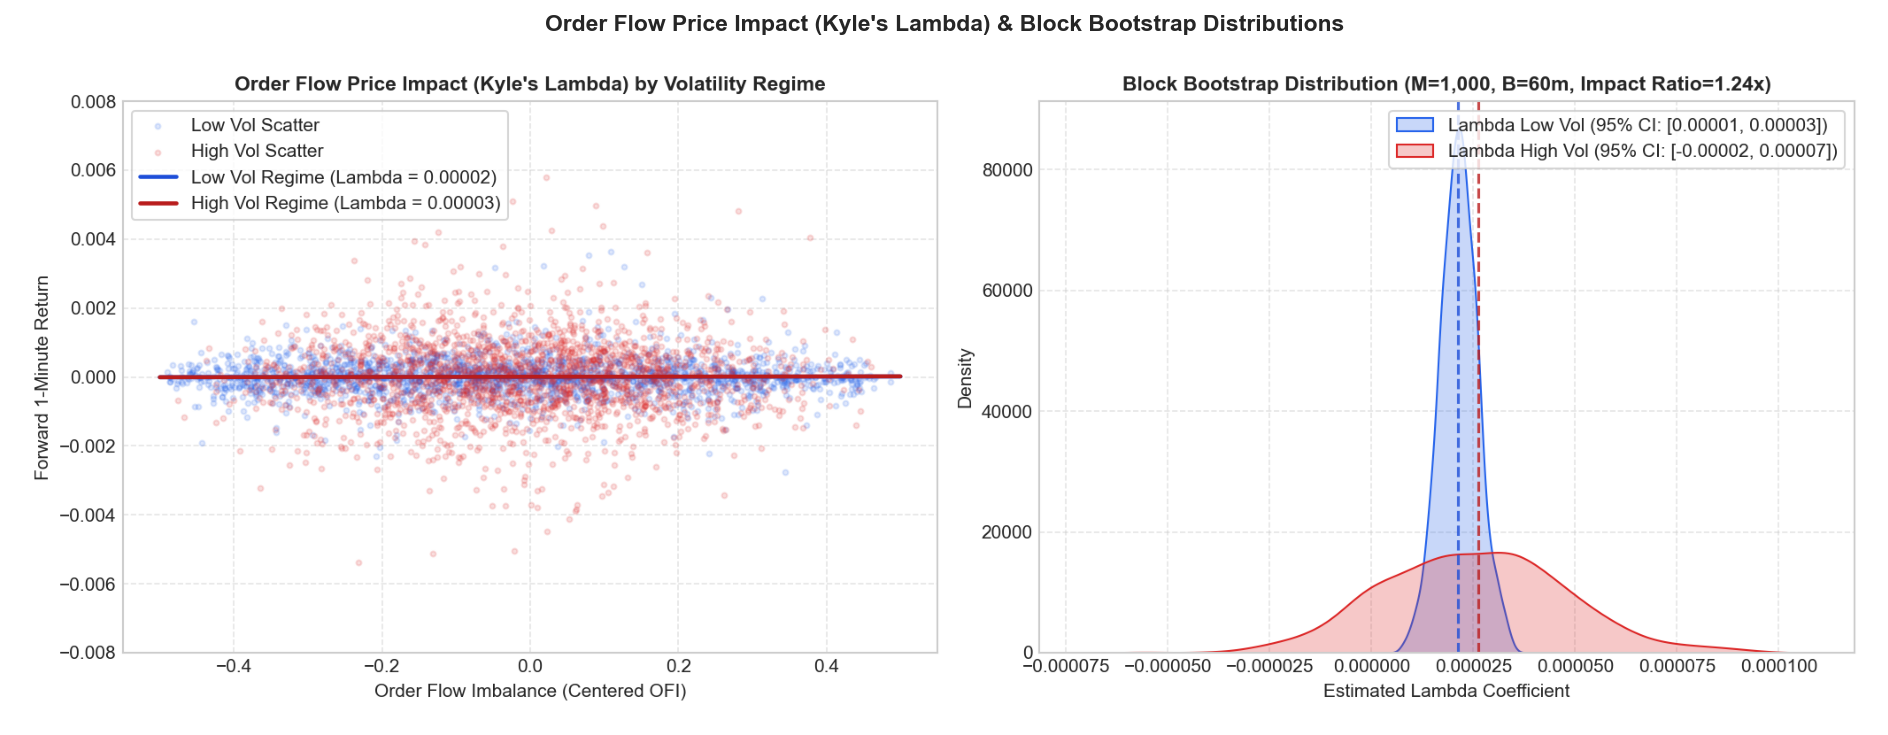

In [6]:
# Tải và hiển thị biểu đồ đã kết xuất
from PIL import Image
if figure_save_path.exists():
    fig_img = Image.open(figure_save_path)
    plt.figure(figsize=(14, 5), dpi=150)
    plt.imshow(fig_img)
    plt.axis("off")
    plt.title("Order Flow Price Impact (Kyle's Lambda) & Block Bootstrap Distributions", pad=12)
    plt.tight_layout()
    plt.show()
else:
    print("Biểu đồ chưa được kết xuất tại đường dẫn chỉ định.")

---
## PHẦN 8: Thảo luận hạn chế của dữ liệu & Lộ trình nâng cấp chiến lược

### 1. Hạn chế kỹ thuật của dữ liệu 1 phút OHLCV thô:
- **Hiện tượng che giấu cấu trúc vi mô (Aggregation Bias):** Dữ liệu nến 1 phút nén hàng ngàn lệnh khớp thành một nến duy nhất, làm mất thứ tự khớp lệnh chi tiết (execution sequence) và không ghi nhận được các cú sốc thanh khoản cấp millisecond.
- **Thiếu thông tin sổ lệnh giới hạn (Limit Order Book Depth):** Biến `taker_buy_volume` chỉ phản ánh các lệnh thị trường đã khớp, không đo lường được độ sâu các bước giá chờ (Bid/Ask Queue Depth), dẫn đến việc đánh giá áp lực giá chỉ dựa trên dòng lệnh thực thi mà chưa tính đến độ co giãn của thanh khoản thụ động.
- **Giả định trượt giá tuyến tính:** Mô hình Kyle's Lambda OLS giả định tác động giá tuyến tính, trong khi các lệnh kích thước lớn trong thực tế thường gây ra tác động thị trường phi tuyến tính dạng căn bậc hai (Square-Root Law of Price Impact).

### 2. Định hướng nghiên cứu mở rộng trong tương lai:
- **Nâng cấp sang dữ liệu Tick & Level 2/3 Order Book:** Cho phép tính toán chính xác chỉ số xác suất độc hại đồng bộ hóa theo khối lượng **VPIN (Volume-Synchronized Probability of Toxicity)** và tỷ lệ mất cân bằng sổ lệnh đa tầng (Multi-Level Order Book Imbalance).
- **Xây dựng thuật toán giao dịch thích ứng (Adaptive Execution Engine):** Tích hợp hệ số Kyle's Lambda động vào mô hình tối ưu hóa Almgren-Chriss hoặc các thuật toán học tăng cường (Reinforcement Learning - PPO/SAC) để tự động điều chỉnh tốc độ khớp lệnh (execution pacing) nhằm giảm thiểu trượt giá (Slippage) khi bước vào các giai đoạn thị trường độc hại.